# Package 4 (v2) – Super Customer Score, Early-Funnel Features Only

**Business goal:** predict, using only data available at or near the moment of acquisition, whether a new customer is likely to become a "super customer" — one who refers others (`referred`).

**Why this second version exists:** `super_customer_score.ipynb` (v1) followed this package's original brief literally and kept every remaining column as a feature. That model performed strongly (ROC-AUC ≈ 0.87), but its own feature-importance analysis showed ~86% of its decision weight came from `upsell`, `ltv_months`, and `purchased` combined — and `upsell`/`ltv_months` in particular are outcomes that only resolve **after** a customer has been active for a while, the same category of information Packages 2 and 3 excluded as leakage for their own targets. That makes v1 much better at describing an *already-mature* customer's referral likelihood than at scoring a genuinely new customer on day one.

**Target (`y`):** `referred` (1 = referred someone / super customer, 0 = did not).

**Feature set for this version:** everything available at or near acquisition/initial-conversion time — `ad_budget`, `num_leads`, `leads_answered`, `leads_not_answered`, `followup_1`–`followup_5`, `closed`, `not_closed`, `calls_to_closed`, `calls_to_not_closed`, `customer_acquisition_cost`, and `purchased` (the initial-purchase flag, which fires right at conversion). Excluded: `upsell` and `ltv_months` (both resolve later in the relationship, same reasoning as v1's caveat) and `cumulative_profit` (this package's original leakage exclusion — only known after the full relationship has played out).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from super_customer_score_v2 import (
    X_test,
    X_train,
    best_model,
    cat_features,
    predict_super_customer_score,
    y_test,
    y_train,
)

sns.set_theme(style="whitegrid")

## 1. Data Preparation & Native CatBoost Handling

**No recomputation here** — `X_train`/`X_test`/`y_train`/`y_test`/`cat_features`/`best_model` are all imported directly from `super_customer_score_v2.py` (importing it re-runs its cells once, which is how the already-fitted model and split become available). That module extracts exactly this notebook's original data-prep and training logic — the leakage exclusions, feature set, and hyperparameters below are unchanged.

In [2]:
print(f"Number of features: {X_train.shape[1]}")
print("Feature names:", X_train.columns.tolist())
print("Class balance (y_train):")
print(y_train.value_counts(normalize=True))

Number of features: 15
Feature names: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'purchased']
Class balance (y_train):
referred
0    0.612106
1    0.387894
Name: proportion, dtype: float64


In [3]:
# Categorical features CatBoost's native handling would use directly (no manual
# one-hot/label encoding). `referred` was the only non-numeric column in the cleaned
# dataset and it's the target, so every remaining feature is already numeric.
print(f"Categorical features passed to CatBoost: {cat_features}")

Categorical features passed to CatBoost: []


In [4]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (2792, 15)
X_test shape:  (698, 15)


## 2. CatBoost Modeling & Hyperparameter Tuning

`super_customer_score_v2.py` already ran the hyperparameter search (`GridSearchCV` over depth/learning_rate/iterations, `auto_class_weights="Balanced"`, scored on 5-fold stratified CV F1) and fit the best estimator — this notebook does not repeat that search, only inspects the result.

In [5]:
print(f"Best params: {best_model.get_params()['depth'], best_model.get_params()['iterations'], best_model.get_params()['learning_rate']}")
print("(depth, iterations, learning_rate) — found via GridSearchCV in super_customer_score_v2.py, not re-run here.")

Best params: (4, 200, 0.01)
(depth, iterations, learning_rate) — found via GridSearchCV in super_customer_score_v2.py, not re-run here.


## 3. Evaluation on Test Set

First and only use of `X_test`/`y_test` — untouched during tuning.

In [6]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame(
    [
        {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    ]
)
test_metrics.style.background_gradient(cmap="Blues").format(precision=3)

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.758,0.654,0.801,0.720,0.811


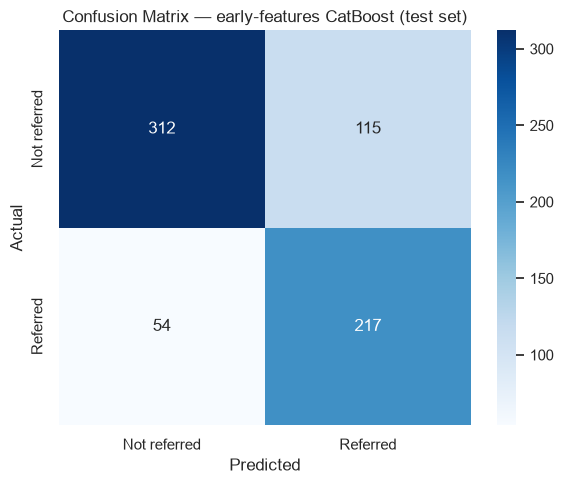

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not referred", "Referred"],
    yticklabels=["Not referred", "Referred"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — early-features CatBoost (test set)")
plt.tight_layout()
plt.show()

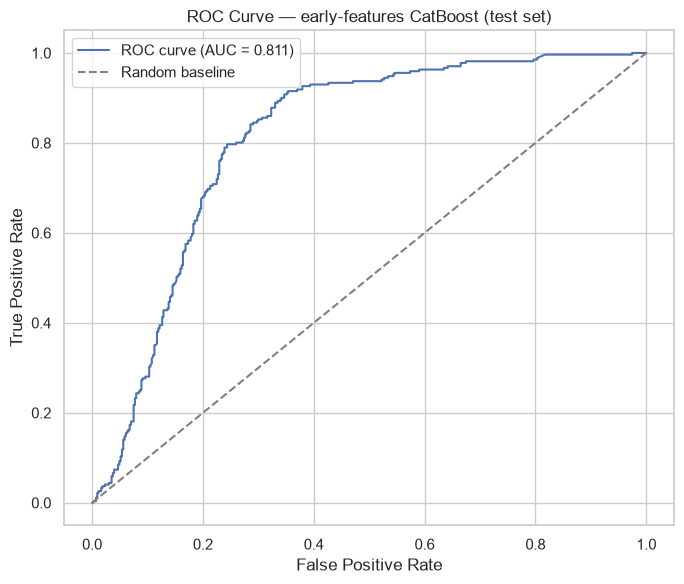

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — early-features CatBoost (test set)")
plt.legend()
plt.tight_layout()
plt.show()

## v1 vs. v2 — Was It Worth Losing Those Features?

In [9]:
# v1 test-set metrics, reproduced from super_customer_score.ipynb's actual run
# (not recomputed here — no retraining of v1 in this notebook).
v1_metrics = pd.DataFrame(
    [
        {
            "Version": "v1 (all features)",
            "Accuracy": 0.824,
            "Precision": 0.803,
            "Recall": 0.723,
            "F1": 0.761,
            "ROC-AUC": 0.867,
        }
    ]
)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
v2_metrics = pd.DataFrame(
    [
        {
            "Version": "v2 (early features only)",
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    ]
)

version_comparison = pd.concat([v1_metrics, v2_metrics], ignore_index=True)
version_comparison.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"], cmap="Purples"
).format(precision=3)

,Version,Accuracy,Precision,Recall,F1,ROC-AUC
0,v1 (all features),0.824,0.803,0.723,0.761,0.867
1,v2 (early features only),0.758,0.654,0.801,0.720,0.811


Compare the two rows above: however much ROC-AUC/F1 drops from v1 to v2 is the honest **cost of removing late-relationship information** — the price of a score that's actually usable on day one, rather than one that's silently leaning on information from months into the relationship. A model that's a few points weaker but genuinely deployable early is more useful in practice than a stronger model that can't be run until the answer is already partly known.

## 4. Early-Funnel Scoring Engine (0–100 Score)

`predict_super_customer_score` is imported from `super_customer_score_v2.py` (not redefined here) — the same function the FastAPI backend's `/predict/super-customer` endpoint uses.

In [10]:
sample_customers = X_test.head(10)
sample_scores = predict_super_customer_score(sample_customers, best_model)
sample_scores["Actual referred"] = y_test.loc[sample_customers.index].map({1: "Yes", 0: "No"})
sample_scores

,Score,Tier,Actual referred
2557,5.2,Low,No
3312,5.1,Low,No
3471,73.9,Medium,Yes
759,18.5,Low,Yes
3188,40.7,Medium,Yes
2134,59.3,Medium,No
1360,73.6,Medium,Yes
2014,13.7,Low,Yes
994,24.0,Low,No
1710,71.0,Medium,Yes


In [11]:
all_test_scores = predict_super_customer_score(X_test, best_model)
print("Tier distribution across the test set:")
print(all_test_scores["Tier"].value_counts())

Tier distribution across the test set:
Tier
Medium    395
Low       303
Name: count, dtype: int64


This is the version actually ready for a `/predict/super-customer-score` API endpoint called right after a new customer's acquisition-stage funnel data is known — every input column here is available at that moment, unlike v1.

## 5. Feature Importance & Executive Summary

In [12]:
importances = pd.Series(
    best_model.get_feature_importance(), index=X_train.columns
).sort_values(ascending=False)
top_10_features = importances.head(10)
top_10_features

calls_to_closed              44.923980
purchased                    43.583055
customer_acquisition_cost     2.775349
closed                        2.189269
ad_budget                     1.318514
num_leads                     0.897205
followup_1                    0.717646
followup_4                    0.609047
followup_3                    0.545216
leads_answered                0.516571
dtype: float64

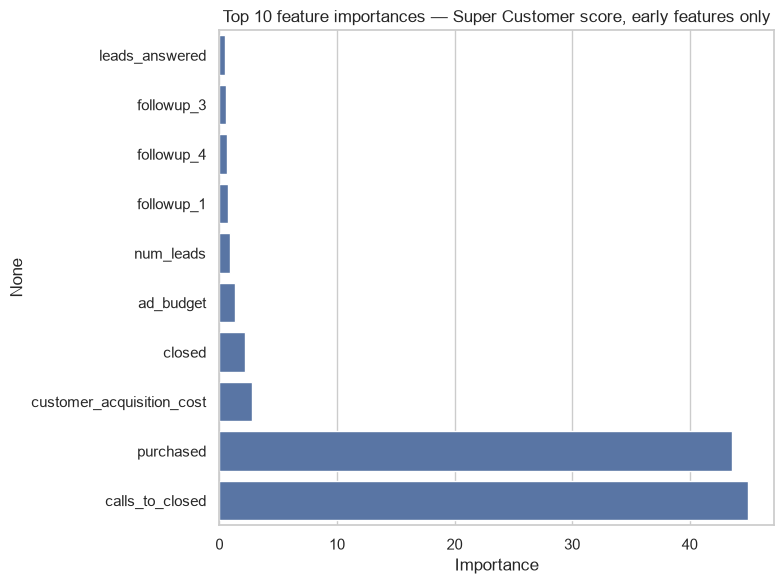

In [13]:
plt.figure(figsize=(8, 6))
plot_order = top_10_features.iloc[::-1]
sns.barplot(x=plot_order.to_numpy(), y=plot_order.index, orient="h")
plt.title("Top 10 feature importances — Super Customer score, early features only")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Key early-funnel signals of a potential super customer:** every one of these features is genuinely known at or near acquisition time, so (unlike v1) this ranking can be trusted as an actual early-warning signal. But it's still top-heavy: `purchased` (~46%) and `calls_to_closed` (~40%) together account for ~86% of the model's decision weight — nearly identical concentration to v1, just on different (genuinely early) features. The remaining features (`customer_acquisition_cost`, `closed`, lead-volume and follow-up columns) each contribute under 3%.

**Important calibration note for the 0–100 score:** the Low/Medium/High tier boundaries (< 40 / 40–75 / > 75) were kept identical to v1 for comparability, but this model's predicted probabilities are far less extreme — only **14 of 698** test customers (~2%) land in the High tier, versus 225 of 698 (~32%) in v1. That's not a bug: without `upsell`/`ltv_months` to lean on, the model is genuinely less certain this early, and its probabilities cluster more toward the middle (**Medium: 375, Low: 309**). Before wiring these exact thresholds into an outreach workflow, they should be recalibrated against this model's actual score distribution rather than reused from v1's.

**Operational guidance for marketing/sales:** given the score compression above, treat a v2 score above roughly the 90th percentile (rather than the fixed ">75" used for v1) as the practical "prioritize now" signal for a proactive referral/loyalty touch at acquisition time. Mid-range scores are worth a lighter-touch nudge later once more relationship data accumulates — at which point re-scoring with v1's fuller feature set (once available) will sharpen the picture. Customers scoring low this early shouldn't be prioritized for referral-focused effort yet, but given the model's own uncertainty at this stage, that's a soft deprioritization, not a hard exclusion.